In [1]:
_repo_root = !git rev-parse --show-toplevel
%cd {_repo_root[0]}
del _repo_root

/Users/alex.shtoff/git/spectral_neuron_paper


# Bivariate fitting

Loads, summarizes, and plots persisted bivariate experiment results.


In [2]:
import matplotlib as mpl
import pandas as pd

from paper.experiments import synthetic
from paper.plotting import plot_bivariate_target_gallery, plot_scaling
from paper.targets import TargetSpec
from paper.tuning import summarize_raw

mpl.rcParams["figure.dpi"] = 140


In [3]:
profile_name = "small"
raw_path = synthetic.default_raw_path("bivariate", profile_name)
plot_target_kind = "general"

In [4]:
if not raw_path.exists():
    raise FileNotFoundError(
        f"{raw_path} does not exist; run paper.experiments.bivariate first"
    )

raw = pd.read_csv(raw_path)

summary = summarize_raw(raw)
plot_summary = summary.loc[summary["target_kind"] == plot_target_kind].copy()
plot_summary.head()

,target_kind,complexity,noise_std,model,dim,batch_size,train_size,selected_lr,median_test_rmse,q25_test_rmse,q75_test_rmse,n
0,general,5,0.0,unconstrained,5,32,32,0.1,1.168105,1.060904,1.233697,16
1,general,5,0.0,unconstrained,5,32,64,0.1,1.006721,0.936418,1.149591,16
2,general,5,0.0,unconstrained,5,32,160,0.1,0.735974,0.640464,0.920986,16
3,general,5,0.0,unconstrained,5,32,320,0.1,0.651951,0.559944,0.816583,16
4,general,5,0.0,unconstrained,5,32,640,0.1,0.570737,0.486668,0.658231,16


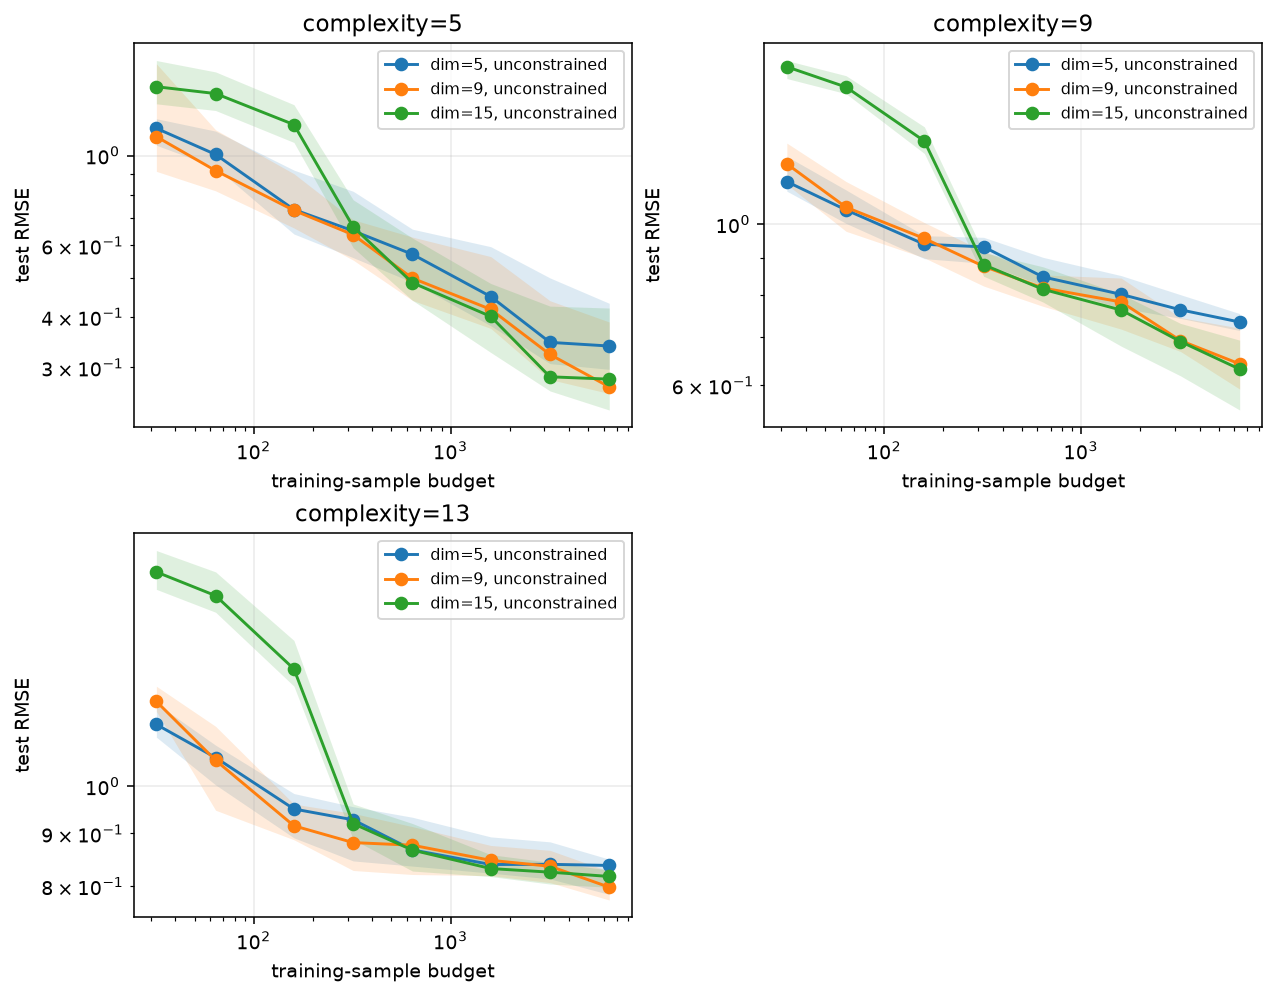

In [5]:
plot_scaling(plot_summary);

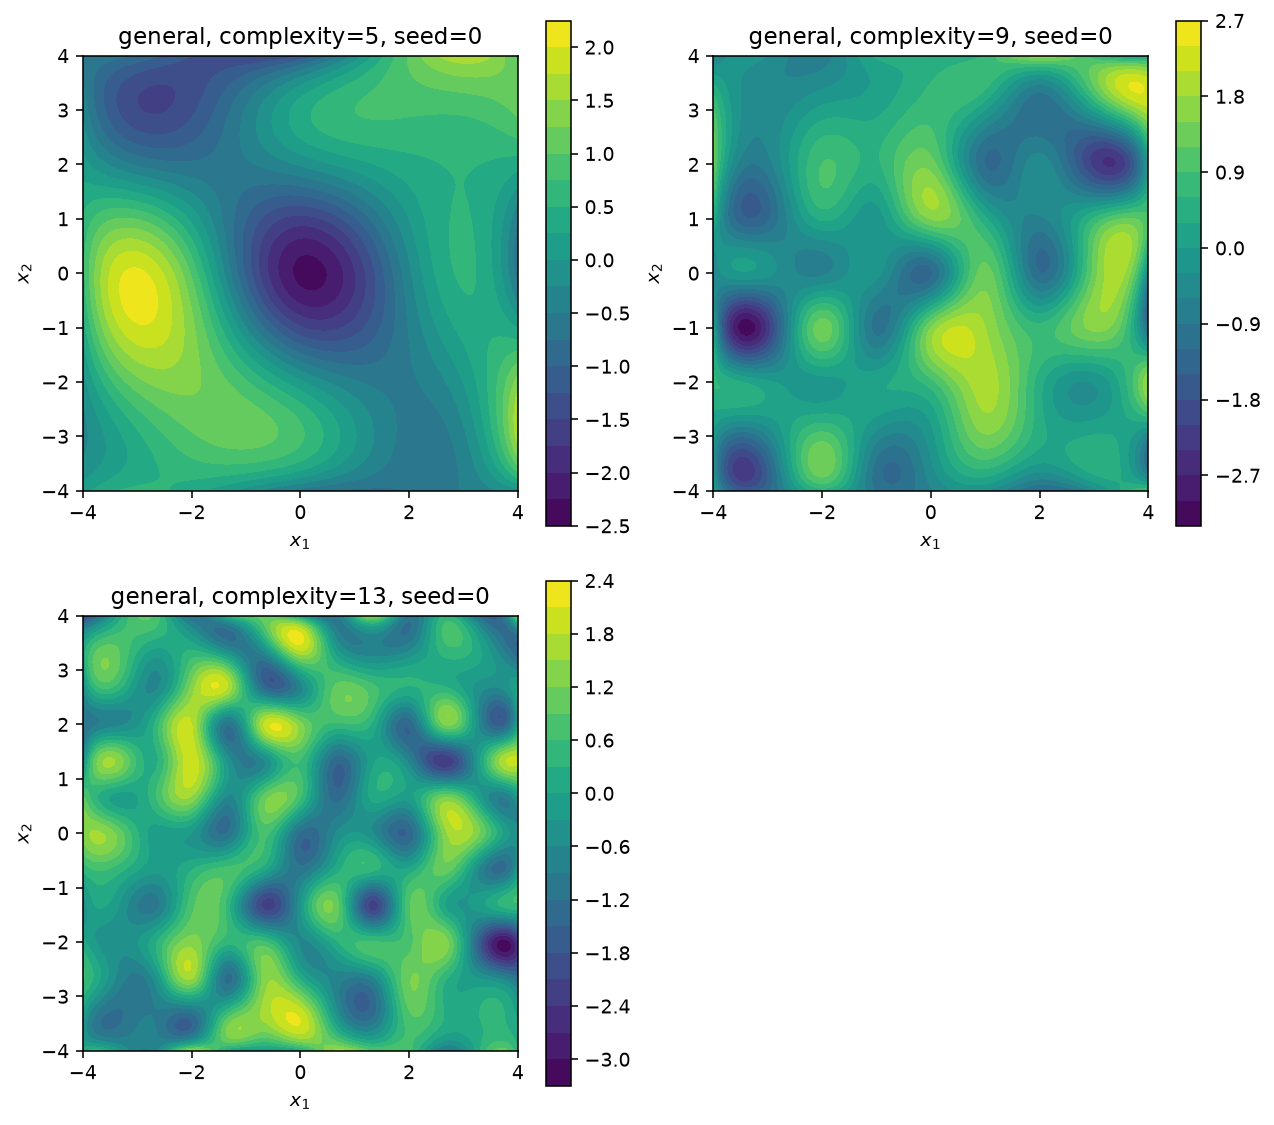

In [6]:
plot_bivariate_target_gallery([
    TargetSpec(kind=plot_target_kind, complexity=complexity, seed=0)
    for complexity in sorted(plot_summary["complexity"].unique())
]);